<a href="https://colab.research.google.com/github/arteagac/arteagac.github.io/blob/master/blog/lime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interpretable Machine Learning with LIME 
By: Cristian Arteaga, [arteagac.github.io](https://arteagac.github.io)

![Image](https://arteagac.github.io/blog/lime/img/banner.png)

In this step by step guide with python code, we will study the details behind a popular technique for interpretable machine learning called LIME (Local Interpretable Model-agnostic Explanations). This technique was proposed by Rubiero et. al. in their paper "Why should I trust you?: Explaining the predictions of any classifier" on 2016 ([See paper here](https://arxiv.org/abs/1602.04938)). 

The example developed in this notebook is for explanations of tabular data. However, it is worth to highlight that this technique can also be applied for explanations with text and image data. For a brief introduction about of the need for interpretability and a short overview of LIME you can check [these sildes](https://arteagac.github.io/blog/lime/lime_intro_slides.pdf) and/or the YouTube video below.

In [7]:
%%HTML
<iframe src="https://www.youtube.com/embed/vz_fkVkoGFM" width="560" height="315"  allowfullscreen></iframe>

## Initialization

### Imports and global settings
Regular python tools for data manipulation and plotting are imported. In addition, a function to set the style of plots is declared. 

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from  matplotlib.colors import LinearSegmentedColormap
gray_cmap=LinearSegmentedColormap.from_list('gy',[(.3,.3,.3),(.8,.8,.8)], N=2)
np.random.seed(222) #Seed for random numbers generation

def set_plot_style():
  plt.axis([-2,2,-2,2])
  plt.xlabel('x1')
  plt.ylabel('x2')

### Read and standarize data
An artificial dataset with two explanatory variables as input and one categorical binary variable as output is used here. This dataset was manually designed to intentionally represent an underlying data generation process with non-linear decision boundaries. The first 5 elements of this dataset and a plot of the underlying data generation process are shown below.

In [0]:
df = pd.read_csv("https://arteagac.github.io/blog/lime/artificial_data.csv",header = 'infer')
df[0:5]

,x1,x2,y
0,14.48,27.10,0
1,13.83,26.85,0
2,13.18,26.70,0
3,12.53,26.50,0
4,11.58,26.25,0


The explanatory variables are saved in the array `X` and the output in `y`. To avoid issues due to the units of the explanatory variables the data is standarized using normal standarization. This is a regularly recommended practice in machine learning. 

In [0]:
X = df[['x1','x2']].values
y = df['y'].values
X = (X - np.mean(X,axis=0)) / np.std(X,axis=0) #Standarization of data

The following plot represents the underlying data generation process in the dataset. The axis represent the input variables `x1` and `x2` and the color (soft and dark gray) represent the class that the element belongs to. 

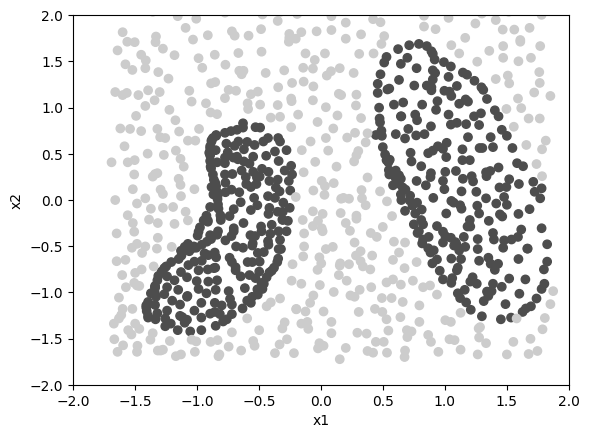

In [0]:
set_plot_style()
plt.scatter(X[:,0],X[:,1], c=y, cmap=gray_cmap)

### Train a machine-learning classifier
A random forest classifier is trained with the previous data. Remember that this is a binary classification problem. 

In [0]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100)
classifier.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

A mesh grid is created in order to observe the decision boundaries of the trained classifier. If you are not familiar with concept of mesh grid or plotting of decision boundaries you can think of it as sampling a lot of `x1` and `x2` values in a specific range and use the machine learnig classifier to predict the output and visually observe the decision boundaries fo the trained model. The plot shown below illustrates the decision boundaries of the classifier and it can be noted that they are very similar to the underlying data generation process. Even though we should always control for overfitting, in this case it is not necessarily a problem because we can visually inferr that the decision boundaries of the classifier match the data generation process.

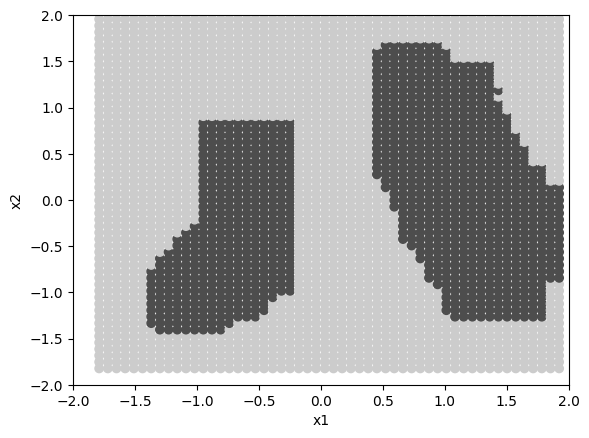

In [0]:
#Function to create a mesh grid
def make_meshgrid(x1, x2, h=.02,x1_min=0,x1_max=0,x2_min=0,x2_max=0):
    if x1_min==0 and x1_max==0 and x2_min==0 and x2_max==0:
        x1_min, x1_max = x1.min() - 0.1, x1.max() + 0.1
        x2_min, x2_max = x2.min() - 0.1, x2.max() + 0.1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, h), np.arange(x2_min, x2_max, h))
    return np.vstack((xx1.ravel(), xx2.ravel())).T

#Create mesh grid and predict class for each element in mesh grid
XX = make_meshgrid(X[:,0],X[:,1],h=.07)
yy = classifier.predict(XX)

set_plot_style()
plt.scatter(XX[:,0],XX[:,1], c=yy, cmap=gray_cmap)

## LIME Explanations
LIME generates local explanations, in other words, explanations for individual instances in a dataset. LIME starts by generating a new dataset of perturbations around the instance to be explained. Then, the trained machine learning classifier is used to predict the class of each instance in the new generated dataset. Finally, a simpler model with intrinsic intepretability, for instance a linear regression model, is fitted and used to explain the prediction of the classifier. Before fitting a simpler model, the instances in the new generated dataset are weighed based on their distance to the original instance being explained. In this way, there is a higher certainty that the model is locally faithful around the explained instance. 

In this example, as shown in the plot below, we want to explain the prediction of the blue dot (instance with x1 = 0.8 and x2 = -0.7).

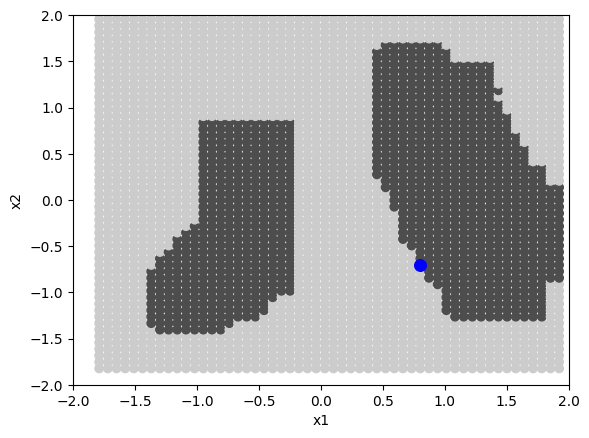

In [0]:
Xi = np.array([0.8,-0.7])
set_plot_style()
plt.scatter(XX[:,0],XX[:,1], c=yy, cmap=gray_cmap)
plt.scatter(Xi[0],Xi[1],c="blue",marker="o",s=70 )

### Step 1. Generate random perturbations around the instance being explained
For the case of tabular data, sampling around the mean and standard deviation of the explanatory variables is recommended. Given that the dataset used in this example was normally standarized in a previous step, a normal random sample with mean 0 and standard deviation 1 is generated and stored in the 2D array `X_lime` as shown below. At this point, we still do not know the class for each element in this sample. Such class is predicted in the next step.

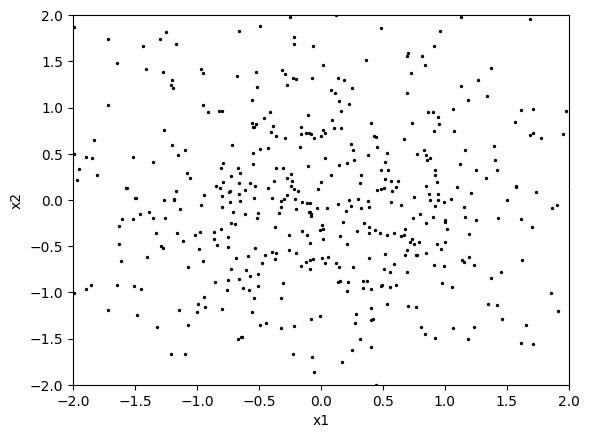

In [0]:
num_perturb = 500
X_lime = np.random.normal(0,1,size=(num_perturb,X.shape[1]))

set_plot_style()
plt.scatter(X_lime[:,0],X_lime[:,1],s=2,c="black")

### Step 2: Use ML classifier to predict classes of new generated dataset
The random forest classifier trained in previous steps is used here to predict the class of each pair (x1,x2) in the new generated dataset.

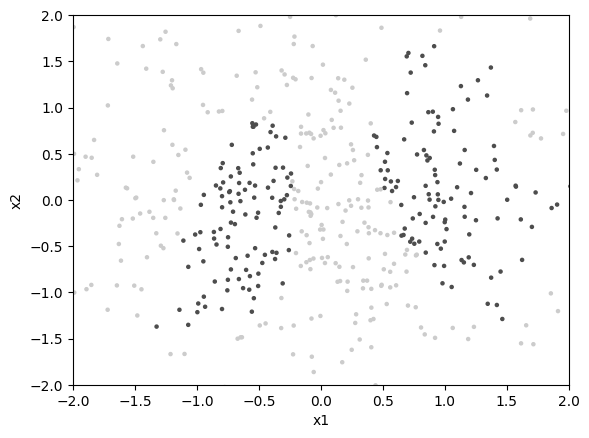

In [0]:
y_lime = classifier.predict(X_lime)
set_plot_style()
plt.scatter(X_lime[:,0],X_lime[:,1],s=5, c=y_lime, cmap=gray_cmap)

In [0]:
classifier.predict(np.array([0.8,-0.7]).reshape(1, -1) )


array([1])

### Step 3: Compute distances between the instance being explained and each perturbation and compute weights (importance) of the generated instances
The distance between each randomly generated instance and the instance being explained is computed using the euclidean distance. For explanations of other types of data such as image or text data the cosine distance can be used. Such distances are then mapped to a value between zero and one (weight) using a kernel function. Depeding on how we set the kernel width it shows how wide we define the "locality" around our instance. For tabular data the definition of a kernel width needs special atention, specially if the data has not been standarized. A more detailed discussion on this topic of kernel width can be found in the book ["Interpretable Machine Learning" by Cristoph Molnar](https://christophm.github.io/interpretable-ml-book/) in section 5.7. In the code below, the shape of the weights is shown and it can be noted that for each instance in the new randomly generated dataset, there is a corresponding weight or importance value.

In [0]:
kernel_width = 0.2
distances = np.sum((Xi - X_lime)**2,axis=1) #Euclidean distance
weights = np.sqrt(np.exp(-(distances**2)/(kernel_width**2))) #Kernel function
weights.shape

(500,)

The plot below shows how these weights would look like around the instance being explained. Green markers represent larger weights or instance with higher importance.

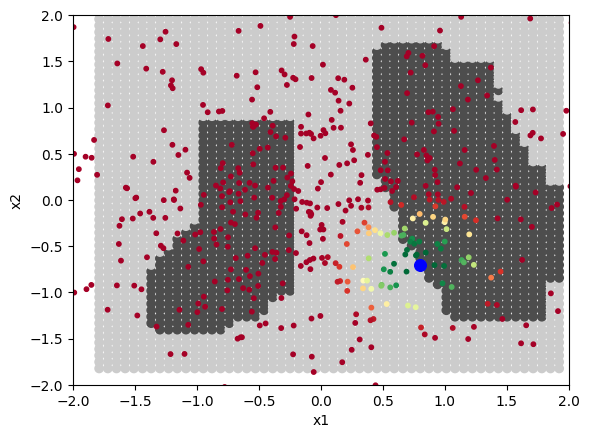

In [0]:
set_plot_style()
plt.scatter(XX[:,0],XX[:,1], c=yy, cmap=gray_cmap)
plt.scatter(X_lime[:,0],X_lime[:,1],s=10,c= weights,cmap="RdYlGn")
plt.scatter(Xi[0],Xi[1],c="blue",marker="o",s=70 )

### Step 4: Use the new generated dataset (`X_lime`), its class predictions (`y_lime`) and their importance (`weights`) to fit simpler and interpretable (linear) model
A linear model is fitted as shown below. This linear model generates new decision boundaries that are locally faitful around the explained instance. This linear decision boundary can be seen with the markers with + and - symbol. It is important to emphasize that this new linear decision boundary is not globally faithful because it is supposed to be a proper discriminator only in the locallity of the instance being explained (blue dot). 

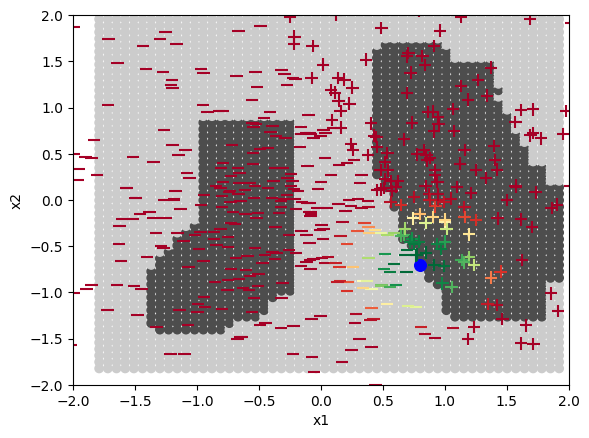

In [0]:
from sklearn.linear_model import LinearRegression
simpler_model = LinearRegression()
simpler_model.fit(X_lime, y_lime, sample_weight=weights)
y_linmodel = simpler_model.predict(X_lime)
y_linmodel = y_linmodel < 0.5 #Conver to binary class

set_plot_style()
plt.scatter(XX[:,0],XX[:,1], c=yy, cmap=gray_cmap)
plt.scatter(Xi[0],Xi[1],c="blue",marker="o",s=70 )
plt.scatter(X_lime[y_linmodel==0,0],X_lime[y_linmodel==0,1],c= weights[y_linmodel==0],cmap="RdYlGn",marker="_",s=80)
plt.scatter(X_lime[y_linmodel==1,0],X_lime[y_linmodel==1,1],c= weights[y_linmodel==1],cmap="RdYlGn",marker="+",s=80)

The coefficients of this estimated linear model can be used to understand how changes in the explanatoriy variables affect the classification output for the instance being explained. For example, as shown below, the estimated coefficients suggest that for the instance being explained, increasing the values of x1 and x2 will cause the prediction to lean towards the prediction of the negative class (darker area).

In [0]:
simpler_model.coef_

array([-1.37295625, -0.61209681])

In this notebook we have studied the basics of how LIME for tabular data works. The concepts covered here are easily transferrable to explanations of other types of data such as text and image data. For an insteresting discussion about some strengths and limitations of LIME please refer to the book ["Interpretable Machine Learning" by Cristoph Molnar](https://christophm.github.io/interpretable-ml-book/).

In [ ]:
from sklearn.linear_model import LinearRegression

def run_lime_and_plot(Xi, title):
    """Run the full 4-step LIME procedure for a given Xi and display results."""
    num_perturb = 500
    kernel_width = 0.2

    # Step 1: generate perturbations
    X_lime = np.random.normal(0, 1, size=(num_perturb, X.shape[1]))

    # Step 2: label with the black-box classifier
    y_lime = classifier.predict(X_lime)

    # Step 3: compute distance-based weights around Xi
    distances = np.sum((Xi - X_lime)**2, axis=1)
    weights = np.sqrt(np.exp(-(distances**2) / (kernel_width**2)))

    # Step 4: fit weighted linear model
    simpler_model = LinearRegression()
    simpler_model.fit(X_lime, y_lime, sample_weight=weights)
    y_linmodel = simpler_model.predict(X_lime) < 0.5

    # Plot: decision surface + weighted perturbations + Xi
    set_plot_style()
    plt.title(title)
    plt.scatter(XX[:,0], XX[:,1], c=yy, cmap=gray_cmap)
    plt.scatter(X_lime[y_linmodel==0,0], X_lime[y_linmodel==0,1],
                c=weights[y_linmodel==0], cmap="RdYlGn", marker="_", s=80)
    plt.scatter(X_lime[y_linmodel==1,0], X_lime[y_linmodel==1,1],
                c=weights[y_linmodel==1], cmap="RdYlGn", marker="+", s=80)
    plt.scatter(Xi[0], Xi[1], c="blue", marker="o", s=100)
    plt.show()

    rf_class = classifier.predict(Xi.reshape(1,-1))[0]
    print(f"RF prediction for Xi: class {rf_class}")
    print(f"LIME coefficients — x1: {simpler_model.coef_[0]:.4f},  x2: {simpler_model.coef_[1]:.4f}")

### Xi 1: `[0.8, -0.7]` — Class 1, near the edge of the right-side class-0 island (notebook default)

This is the original example from the notebook. Xi is predicted as class 1, but it sits just outside the boundary of a class-0 island to the upper-left. Both LIME coefficients come out large and negative, meaning the local linear model says "increasing either feature pushes this prediction toward class 0." This reflects how close Xi is to that island — the dominant local structure is the class-0 boundary nearby.

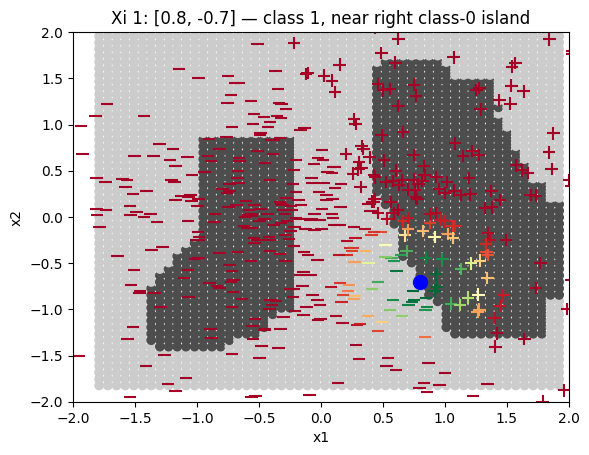

RF prediction for Xi: class 1
LIME coefficients — x1: -1.2910,  x2: -0.6439


In [ ]:
Xi = np.array([0.8, -0.7])
run_lime_and_plot(Xi, "Xi 1: [0.8, -0.7] — class 1, near right class-0 island")

### Xi 2: `[-0.7, 0.0]` — Deep inside the left class-0 blob

This point sits well inside the large class-0 region on the left side of the feature space. The LIME coefficients here are noticeably weaker (small magnitude) compared to Xi 1. The reason: when Xi is far from any decision boundary, almost none of the 500 random perturbations cross into the other class — so the weighted linear model has little boundary signal to fit. This demonstrates that **LIME explanations are most informative near decision boundaries**.

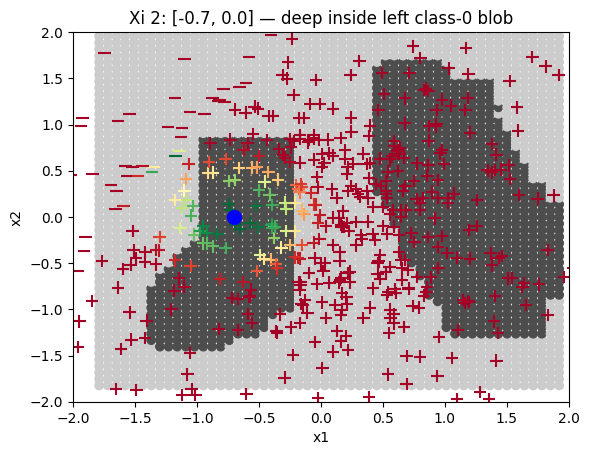

RF prediction for Xi: class 0
LIME coefficients — x1: -0.3085,  x2: 0.2063


In [ ]:
Xi = np.array([-0.7, 0.0])
run_lime_and_plot(Xi, "Xi 2: [-0.7, 0.0] — deep inside left class-0 blob")

### Xi 3: `[-0.1, 0.3]` — Class 1, just outside the left class-0 blob boundary

This point is predicted class 1, but it sits just to the right of the left class-0 region's boundary. The LIME coefficient for x1 is large and positive — meaning "increasing x1 moves this prediction strongly toward class 1." That makes geometric sense: moving left (decreasing x1) from this Xi would cross into class 0, so x1 is the dominant axis here. Notice that x2 barely matters — the boundary at this location runs roughly vertically, making x1 the key feature and x2 nearly irrelevant.

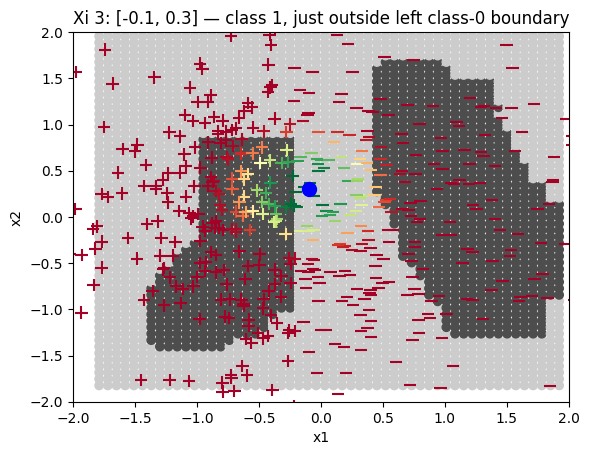

RF prediction for Xi: class 1
LIME coefficients — x1: 1.1438,  x2: 0.0174


In [ ]:
Xi = np.array([-0.1, 0.3])
run_lime_and_plot(Xi, "Xi 3: [-0.1, 0.3] — class 1, just outside left class-0 boundary")

### Xi 4: `[1.5, -1.5]` — Deep class-1, far bottom-right corner

This point is solidly in class 1 and far from all class-0 regions. Yet the LIME coefficient for x2 is large and negative — increasing x2 (moving upward) pushes the prediction toward class 0. This is because moving upward from the bottom-right corner takes you toward the right-side class-0 island. Even from a distance, LIME's local linear model picks up the direction of the nearest threat. This is a good example of how LIME captures the *direction* toward the nearest decision boundary, not just whether you are currently near one.

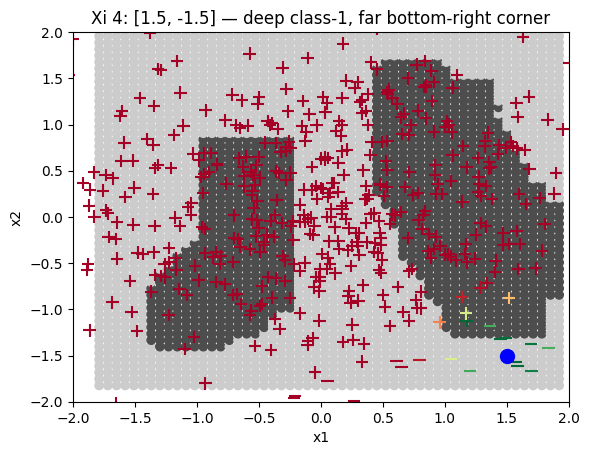

RF prediction for Xi: class 1
LIME coefficients — x1: 0.4348,  x2: -1.0678


In [ ]:
Xi = np.array([1.5, -1.5])
run_lime_and_plot(Xi, "Xi 4: [1.5, -1.5] — deep class-1, far bottom-right corner")